In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style('whitegrid')

In [ ]:
# NUMPY EXAMPLE 1: Ride Duration Statistics
# We have 10 sample ride durations (minutes). Let's analyse them.

ride_durations = np.array([12, 25, 8, 45, 30, 18, 22, 15, 37, 28])
#                np.array( )  ← converts a Python list into a NumPy array

print("Ride durations (min):", ride_durations)
print()
print("Average :", np.mean(ride_durations), "min")
print("Longest :", np.max(ride_durations),  "min")
print("Shortest:", np.min(ride_durations),  "min")
print("Median  :", np.median(ride_durations), "min")
print("Std Dev :", round(np.std(ride_durations), 2), "min")

Ride durations (min): [12 25  8 45 30 18 22 15 37 28]

Average : 24.0 min
Longest : 45 min
Shortest: 8 min
Median  : 23.5 min
Std Dev : 10.88 min


In [ ]:
# NUMPY EXAMPLE 2: Surge Pricing
# Uber charges 1.5× during peak hours.
# Multiply ALL fares at once — no loop needed!

base_fares  = np.array([150, 200, 120, 300, 250])   # fares in Rupees
surge_fares = base_fares * 1.5                       # apply to ALL at once

print("Base fares  (₹):", base_fares)
print("Surge fares (₹):", surge_fares)
print()
print("NumPy multiplied all 5 values in one line.")
print("At 1 million rows it would still be one line — and take milliseconds!")

Base fares  (₹): [150 200 120 300 250]
Surge fares (₹): [225. 300. 180. 450. 375.]

NumPy multiplied all 5 values in one line.
At 1 million rows it would still be one line — and take milliseconds!


In [ ]:
np.array([150, 200, 120, 300, 250])

array([150, 200, 120, 300, 250])

In [ ]:

sample_data = {
    'RideID':   [101, 102, 103, 104, 105],
    'Pickup':   ['Airport', 'City', 'Airport', 'City', 'Airport'],
    'Duration': [35, 22, 48, 15, 60],
    'Status':   ['Completed', 'Cancelled', 'Completed', 'Completed', 'No Cars']
}
# Each key   = column name
# Each list  = the values in that column

sample_df = pd.DataFrame(sample_data)
sample_df

,RideID,Pickup,Duration,Status
0,101,Airport,35,Completed
1,102,City,22,Cancelled
2,103,Airport,48,Completed
3,104,City,15,Completed
4,105,Airport,60,No Cars


In [ ]:
df = pd.read_csv('/content/uber-data.csv')
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [ ]:
df.shape

(6745, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [ ]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'])
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


In [ ]:
df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [ ]:
df['RequestHour'] = df['Request timestamp'].dt.hour


In [ ]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8


In [ ]:

def assign_timeslot(hour):
    if   hour <= 4:  return 'Dawn'
    elif hour <= 9:  return 'Early Morning'
    elif hour <= 16: return 'Noon'
    elif hour <= 21: return 'Late Evening'
    else:            return 'Night'

In [ ]:
df['TimeSlot'] = df['RequestHour'].apply(assign_timeslot)
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour,TimeSlot
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11,Noon
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8,Early Morning


In [ ]:
df['Cab Availability'] = df['Status'].apply(
    lambda x: 'Available' if x == 'Trip Completed' else 'Not Available'
)

In [ ]:
df['Cab Availability'].value_counts(normalize= True)

,proportion
Cab Availability,
Not Available,0.580282
Available,0.419718


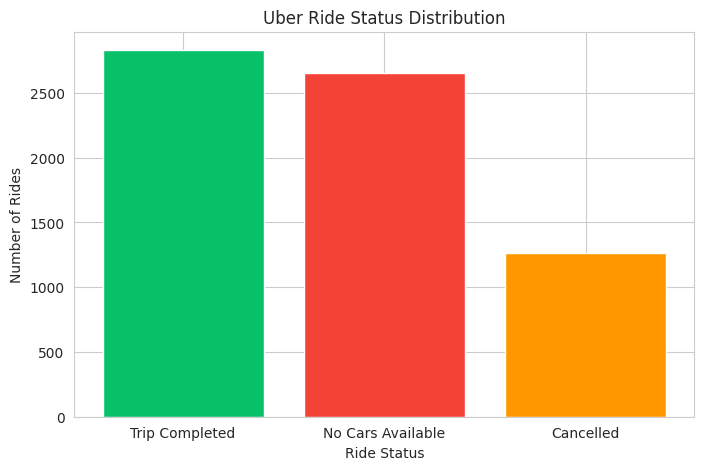

In [ ]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values,
        color=['#06C167', '#F44336', '#FF9800'])
plt.title('Uber Ride Status Distribution')
plt.xlabel('Ride Status')
plt.ylabel('Number of Rides')
plt.show()

In [ ]:
status_counts.index

Index(['Trip Completed', 'No Cars Available', 'Cancelled'], dtype='object', name='Status')

In [ ]:
status_counts.values

array([2831, 2650, 1264])

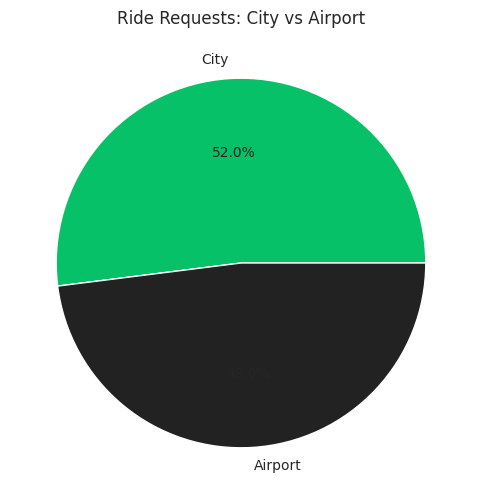

💡 Almost equal split — both routes have problems.


In [ ]:
pickup_counts = df['Pickup point'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(pickup_counts.values,
        labels=pickup_counts.index,
        autopct='%1.1f%%',
        colors=['#06C167', '#222222'])
plt.title('Ride Requests: City vs Airport')
plt.show()

print("💡 Almost equal split — both routes have problems.")

In [ ]:
df['Pickup point'].value_counts()

,count
Pickup point,
City,3507
Airport,3238


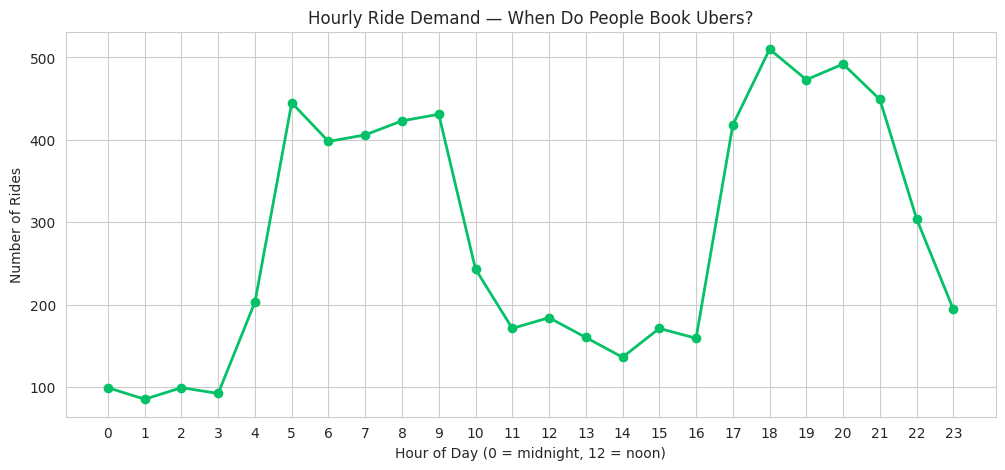

In [ ]:
hourly_demand = df.groupby('RequestHour').size()
# groupby('RequestHour') groups rows by hour
# .size() counts the rows in each group

plt.figure(figsize=(12, 5))
plt.plot(hourly_demand.index, hourly_demand.values,
         color='#06C167', linewidth=2, marker='o')
plt.title('Hourly Ride Demand — When Do People Book Ubers?')
plt.xlabel('Hour of Day (0 = midnight, 12 = noon)')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.show()

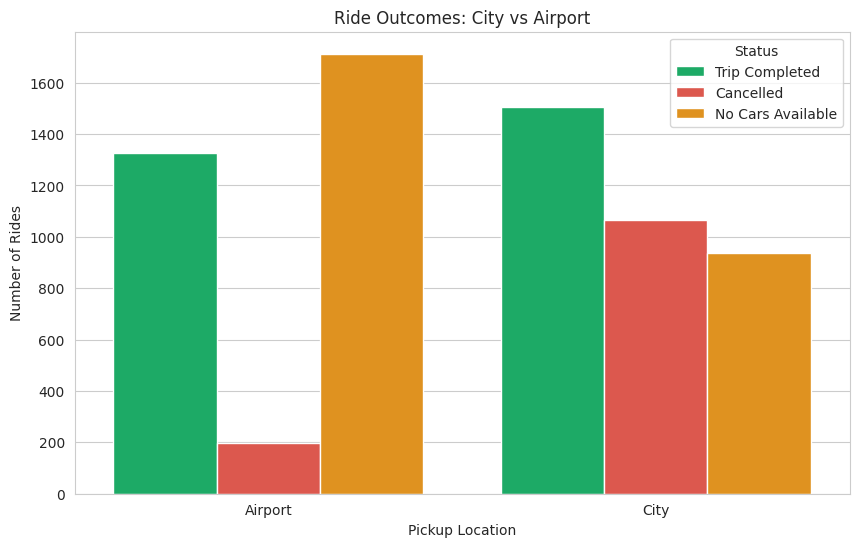

💡 City → HIGH Cancellations | Airport → HIGH No Cars Available
   Two different problems, two different solutions needed!


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df,
              x='Pickup point',
              hue='Status',
              palette=['#06C167', '#F44336', '#FF9800'])
plt.title('Ride Outcomes: City vs Airport')
plt.xlabel('Pickup Location')
plt.ylabel('Number of Rides')
plt.show()

print("💡 City → HIGH Cancellations | Airport → HIGH No Cars Available")
print("   Two different problems, two different solutions needed!")

In [ ]:
df.groupby(['RequestHour', 'Status']).size().unstack(fill_value=0)

Status,Cancelled,No Cars Available,Trip Completed
RequestHour,,,
0,3,56,40
1,4,56,25
2,5,57,37
3,2,56,34
4,51,74,78
5,176,84,185
6,145,86,167
7,169,63,174
8,178,90,155


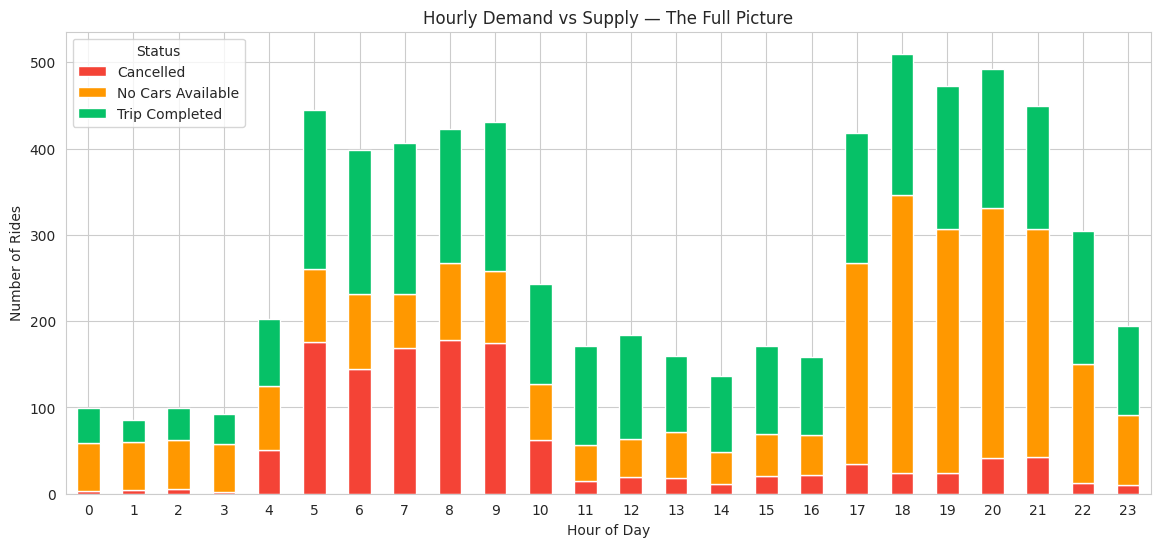

In [ ]:
hourly_status = df.groupby(['RequestHour', 'Status']).size().unstack(fill_value=0)

hourly_status.plot(kind='bar', stacked=True, figsize=(14, 6),
                   color=['#F44336', '#FF9800', '#06C167'])
plt.title('Hourly Demand vs Supply — The Full Picture')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df_city = df[df['Pickup point']== 'City']

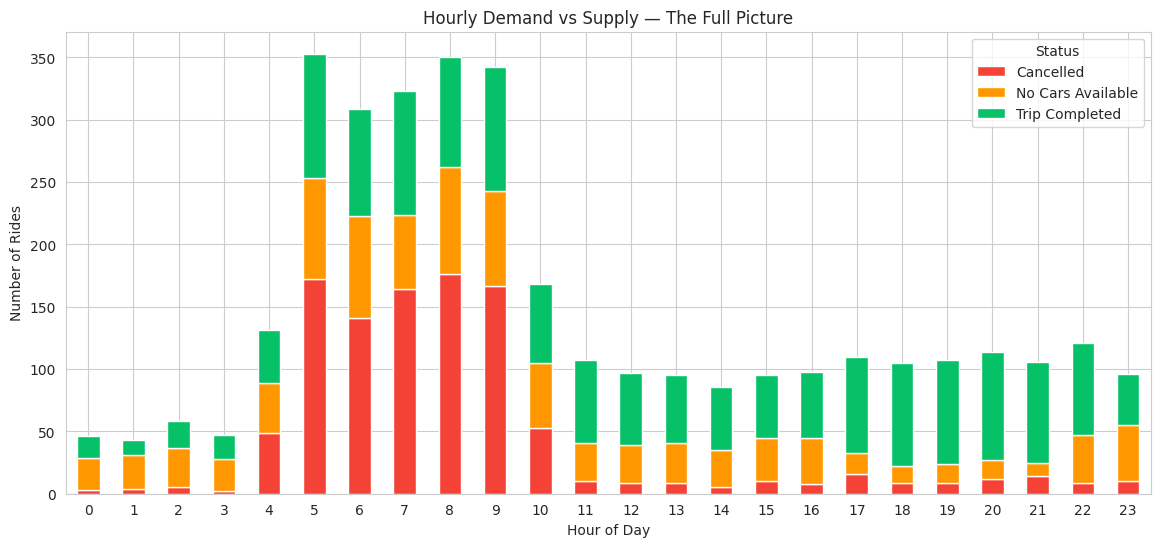

In [ ]:
hourly_status = df_city.groupby(['RequestHour', 'Status']).size().unstack(fill_value=0)

hourly_status.plot(kind='bar', stacked=True, figsize=(14, 6),
                   color=['#F44336', '#FF9800', '#06C167'])
plt.title('Hourly Demand vs Supply — The Full Picture')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df_airport = df[df['Pickup point']== 'Airport']

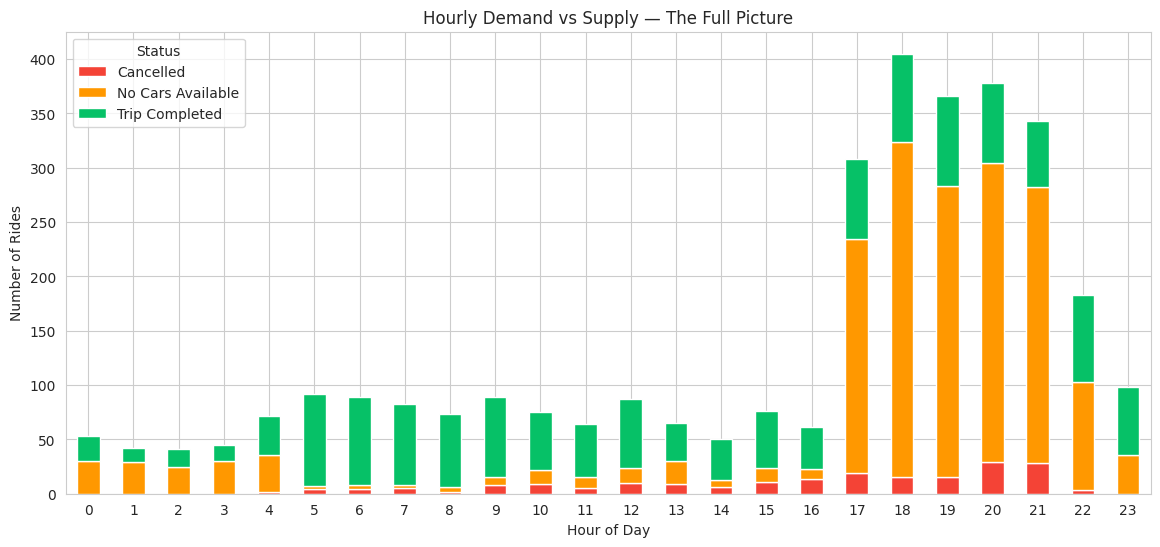

In [ ]:
hourly_status = df_airport.groupby(['RequestHour', 'Status']).size().unstack(fill_value=0)

hourly_status.plot(kind='bar', stacked=True, figsize=(14, 6),
                   color=['#F44336', '#FF9800', '#06C167'])
plt.title('Hourly Demand vs Supply — The Full Picture')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()